In [1]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib_venn

In [2]:
def load_user_embeddings() -> pl.DataFrame:
    splits = {'train': 'data/train-00000-of-00001.parquet', 'test_warm': 'data/test_warm-00000-of-00001.parquet', 'test_cold': 'data/test_cold-00000-of-00001.parquet'}
    df_train = pl.read_parquet("hf://datasets/talkpl-ai/TalkPlayData-Challenge-User-Embeddings/" + splits["train"])
    df_test_warm = pl.read_parquet("hf://datasets/talkpl-ai/TalkPlayData-Challenge-User-Embeddings/" + splits["test_warm"])
    df_test_cold = pl.read_parquet("hf://datasets/talkpl-ai/TalkPlayData-Challenge-User-Embeddings/" + splits["test_cold"])
    
    df_train = df_train.with_columns(pl.lit("train").alias("split"))
    df_test_warm = df_test_warm.with_columns(pl.lit("test_warm").alias("split"))
    df_test_cold = df_test_cold.with_columns(pl.lit("test_cold").alias("split"))

    return pl.concat([df_train, df_test_warm, df_test_cold], how="vertical")

def load_dev_data() -> pl.DataFrame:
    splits = {'train': 'data/train-00000-of-00001.parquet', 'test': 'data/test-00000-of-00001.parquet'}
    df_train = pl.read_parquet("hf://datasets/talkpl-ai/TalkPlayData-Challenge-Dataset/" + splits["train"])
    df_test = pl.read_parquet("hf://datasets/talkpl-ai/TalkPlayData-Challenge-Dataset/" + splits["test"])
    df_train = df_train.with_columns(pl.lit("train").alias("split_dev"))
    df_test = df_test.with_columns(pl.lit("test").alias("split_dev"))
    return pl.concat([df_train, df_test], how="vertical")

def load_user_metadata() -> pl.DataFrame:
    df = pl.read_parquet("hf://datasets/talkpl-ai/TalkPlayData-Challenge-User-Metadata/data/all_users-00000-of-00001.parquet")
    return df

In [3]:
df = load_user_embeddings()
df.head()

user_id,cf-bpr,split
str,list[f64],str
"""5e0690dc-ffcf-41c1-94e5-2fdafc…","[0.001394, -0.001117, … 0.00007]","""train"""
"""c26f5e1c-f352-455f-aaeb-bb2d59…","[-0.000811, -0.001889, … 0.00271]","""train"""
"""3b21a6b1-338d-42c8-aa9c-236835…","[-0.003471, 0.005971, … -0.002615]","""train"""
"""a95c3a54-2962-4fa9-80ff-1bb091…","[0.000716, -0.009839, … -0.000072]","""train"""
"""585f4782-6f0f-4fce-8823-373ca6…","[-0.004334, 0.002392, … 0.001241]","""train"""


In [4]:
df.shape

(9091, 3)

# 単変量解析

# split

In [5]:
df.group_by("split").agg(pl.count())

C:\Users\ken05\AppData\Local\Temp\ipykernel_21136\1021667543.py:1: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  df.group_by("split").agg(pl.count())


split,count
str,u32
"""test_cold""",129
"""train""",8591
"""test_warm""",371


## user_id

In [6]:
df["user_id"][0]

'5e0690dc-ffcf-41c1-94e5-2fdafc4bd4ed'

In [7]:
df["user_id"].value_counts().sort("count", descending=True).head()

user_id,count
str,u32
"""769870ee-d0cd-4ff2-aff4-37f4a6…",2
"""3854714c-c32d-4f17-a617-63e751…",2
"""1def9d8e-9fd8-4ea1-b213-d425b1…",2
"""08038264-fd5f-4381-8b36-0a2b68…",2
"""fc7e1ed5-fdcf-42a2-9143-8007a7…",2


In [8]:
user_id_count = df["user_id"].value_counts().rename({"count": "appearance"})
user_id_count.group_by("appearance").agg(pl.len())

appearance,len
u32,u32
2,371
1,8349


In [9]:
user_id_count_is2 = user_id_count.filter(pl.col("appearance") == 2)
# "test_warm" に含まれている かつ、 "appearance" が 2 の user_id の数を数える
df.filter((pl.col("split") == "test_warm") & (pl.col("user_id").is_in(user_id_count_is2["user_id"]))).shape

C:\Users\ken05\AppData\Local\Temp\ipykernel_21136\1770173966.py:3: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  df.filter((pl.col("split") == "test_warm") & (pl.col("user_id").is_in(user_id_count_is2["user_id"]))).shape


(371, 3)

In [10]:
df.group_by(["split", "user_id"]).agg(pl.len()).sort("len", descending=True).head()

split,user_id,len
str,str,u32
"""train""","""b88b3092-6f69-4efc-bb10-dbd10e…",1
"""train""","""b99c496d-b9c2-479f-bbe5-236033…",1
"""train""","""9c580bf6-fa82-41a9-9c6a-b7af8f…",1
"""train""","""81561251-f0a8-499b-b366-be64a7…",1
"""train""","""38f465e0-eabb-4430-a090-afb131…",1


c:\Users\ken05\Documents\others\music-crs-evaluator\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ken05\Documents\others\music-crs-evaluator\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21253 (\N{CJK UNIFIED IDEOGRAPH-5305}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ken05\Documents\others\music-crs-evaluator\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21547 (\N{CJK UNIFIED IDEOGRAPH-542B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ken05\Documents\others\music-crs-evaluator\.venv\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 38306 (\N{CJK UNIFIED IDEOGRAPH-95A2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ken05\Documents\others\music-cr

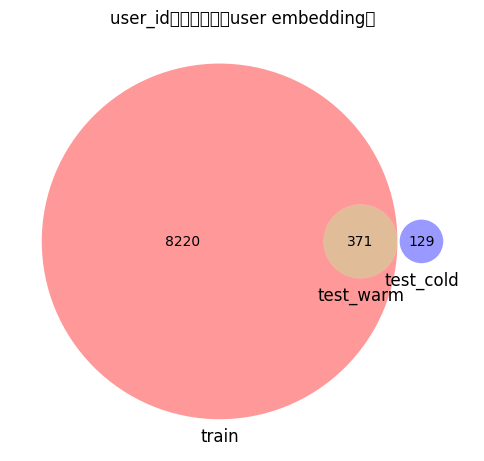

In [11]:
set_train = set(df.filter(pl.col("split") == "train")["user_id"])
set_test_warm = set(df.filter(pl.col("split") == "test_warm")["user_id"])
set_test_cold = set(df.filter(pl.col("split") == "test_cold")["user_id"])

plt.figure(figsize=(6, 6))
venn3 = matplotlib_venn.venn3(
    [set_train, set_test_warm, set_test_cold], 
    set_labels=["train", "test_warm", "test_cold"]
)

plt.title("user_idの包含関係（user embedding）")
plt.show()

### user_embedding
- データ数
  - train ... 8591
  - test_warm ... 371
  - test_cold ... 129
- test_warm かつ count == 2 になるid数 ... 371
  - つまりtest_warmの全てのデータが2回出てくる
- appearanceから、test_coldかつ count == 2のデータはない
- 同じデータセット内で2回同じidが出てくることはない。

# cf-bpr

In [12]:
df["cf-bpr"].head()

cf-bpr
list[f64]
"[0.001394, -0.001117, … 0.00007]"
"[-0.000811, -0.001889, … 0.00271]"
"[-0.003471, 0.005971, … -0.002615]"
"[0.000716, -0.009839, … -0.000072]"
"[-0.004334, 0.002392, … 0.001241]"
"[0.000863, -0.002547, … 0.00004]"
"[-0.000148, -0.000918, … -0.007247]"
"[0.012863, 0.000981, … -0.008897]"
"[0.003417, 0.00174, … 0.004345]"


In [13]:
df.with_columns(pl.col("cf-bpr").list.len().alias("emb_len")).select(pl.col("emb_len").unique())

emb_len
u32
0
128


In [14]:
cf_bpr_len = df.with_columns(pl.col("cf-bpr").list.len().alias("emb_len"))
cf_bpr_len.select(["emb_len", "split"]).group_by(["emb_len", "split"]).agg(pl.len())

emb_len,split,len
u32,str,u32
128,"""train""",8591
128,"""test_cold""",25
0,"""test_cold""",104
128,"""test_warm""",371


In [15]:
cf_bpr_len.filter((pl.col("emb_len") == 128) & (pl.col("split") == "test_cold")).head(10)

user_id,cf-bpr,split,emb_len
str,list[f64],str,u32
"""0b26e17b-0627-45e3-baa1-aa285a…","[0.001365, 0.002224, … -0.002632]","""test_cold""",128
"""9a003c54-6d2d-416e-bef1-dc1d05…","[-0.000827, -0.002198, … -0.001971]","""test_cold""",128
"""cc31cceb-9477-45af-97f6-c64889…","[-0.0035, -0.004494, … -0.00155]","""test_cold""",128
"""1b6cf64c-611b-419e-b9d6-f43f7d…","[0.00001, 0.002219, … -0.00284]","""test_cold""",128
"""fba103ec-2939-402e-8560-5a57a8…","[-0.00345, -0.002423, … 0.001625]","""test_cold""",128
"""b74bae1a-56ad-4cc5-95c1-f72bd8…","[0.000072, 0.001815, … -0.00379]","""test_cold""",128
"""777529e6-7f1a-4b7c-b30b-a2bba9…","[-0.014244, 0.020431, … 0.005433]","""test_cold""",128
"""0cdbcde9-afb1-4ec7-8356-51d324…","[-0.011164, 0.008934, … -0.001034]","""test_cold""",128
"""db93bf83-27ca-47e8-81b3-b43396…","[-0.003385, 0.003455, … 0.00185]","""test_cold""",128


In [16]:
cf_bpr_len.filter((pl.col("emb_len") == 0) & (pl.col("split") == "test_cold")).head(10)

user_id,cf-bpr,split,emb_len
str,list[f64],str,u32
"""e1dac513-ee13-40a1-9bb1-fa69e0…",[],"""test_cold""",0
"""1b8d08b3-f103-4af7-a87b-f3fee8…",[],"""test_cold""",0
"""bb95b750-f90c-4220-bf14-544345…",[],"""test_cold""",0
"""b4c46ecb-3085-4525-875b-a8fa53…",[],"""test_cold""",0
"""653f918b-28b5-46cc-8cbd-bea194…",[],"""test_cold""",0
"""7fb1c25a-8b8a-4270-a1b9-ca5e54…",[],"""test_cold""",0
"""9c9c74f3-e20b-4976-969b-cdcf43…",[],"""test_cold""",0
"""4a79be1f-321a-4352-8ddf-f3c08a…",[],"""test_cold""",0
"""2849bce6-9b66-402f-b49b-948e76…",[],"""test_cold""",0


### cf-bprの0次元の謎をほかのデータと照らし合わせてみる

In [17]:
df_metadata = load_user_metadata()
df_dev = load_dev_data()

df_dev.head(1)

session_id,user_id,session_date,user_profile,conversation_goal,conversations,goal_progress_assessments,split_dev
str,str,str,struct[9],struct[3],list[struct[4]],list[struct[2]],str
"""9c337a02-15b1-408f-8103-c2f945…","""64ea97af-bbc6-4756-ac94-b93104…","""2011-12-26""","{20,""20s"",""BR"",""Brazil"",""female"",""English"",""Western Alternative Rock"",""64ea97af-bbc6-4756-ac94-b931048e5fef"",""train_warm""}","{""H"",""The listener wants to explore different artists and discover new songs from a broad collection, focusing on general moods and styles, without specific genre constraints. They are open to exploring the discographies of artists they find interesting."",""LL""}","[{""I want to discover some new artists. Do you have anything that's a bit intense or dramatic?"",""user"","""",1}, {""81d9f1d9-3b22-4836-9f06-2140e959e6de"",""music"",""You enjoyed the last Alesana track, so I'm sticking with your favorite artist and genre. ""The Fiend"" carries that same intense post-hardcore energy and screamo vocals that define Alesana's sound."",1}, … {""Perfect! Glad to hear it. Let's keep exploring that album with ""The Best Laid Plans Of Mice And Marionettes."" It’s another great one from Alesana with all the post-hardcore goodness you're into."",""assistant"","""",8}]","[{null,1}, {""MOVES_TOWARD_GOAL"",2}, … {""DOES_NOT_MOVE_TOWARD_GOAL"",8}]","""train"""


In [18]:
df_dev = df_dev.with_columns(pl.col("user_profile").struct[-1].alias("split_dev_from_user_profile"))

In [19]:
df_test_cold = df.filter(pl.col("split") == "test_cold")
df_test_cold = df_test_cold.rename({"split": "split_from_user_embedding"})
df_test_cold = df_test_cold.join(df_dev, on="user_id", how="left")
df_test_cold.shape

(263, 11)

In [20]:
df_test_cold.head(1)

user_id,cf-bpr,split_from_user_embedding,session_id,session_date,user_profile,conversation_goal,conversations,goal_progress_assessments,split_dev,split_dev_from_user_profile
str,list[f64],str,str,str,struct[9],struct[3],list[struct[4]],list[struct[2]],str,str
"""e1dac513-ee13-40a1-9bb1-fa69e0…",[],"""test_cold""","""98efe728-b9df-463c-8db7-11511d…","""2020-03-02""","{19,""10s"",""TH"",""Thailand"",""female"",""English"",""Western"",""e1dac513-ee13-40a1-9bb1-fa69e0b77f03"",""test_cold""}","{""B"",""discover multiple songs that explore themes of love, connection, and emotional journeys, focusing on heartfelt lyrics and meaningful storytelling."",""LL""}","[{""I'm looking for songs with really meaningful lyrics about love and connection."",""user"","""",1}, {""230a1144-dd79-4e19-94cc-52355681dc2c"",""music"",""The listener specifically asked for meaningful lyrics about love and connection. ""I Will Spend My Whole Life Loving You"" directly addresses this with its heartfelt and romantic lyrics, fitting perfectly with the Singer/Songwriter genre the listener enjoys."",1}, … {""I'm so happy to hear that ""Pure"" resonated with you! To keep that deeply personal and comforting vibe going, especially focusing on enduring love and finding peace, I highly recommend ""Wilderness"" by Jon Bryant. I think its lyrical depth and emotional sincerity will really speak to you."",""assistant"","""",8}]","[{null,1}, {""MOVES_TOWARD_GOAL"",2}, … {""MOVES_TOWARD_GOAL"",8}]","""test""","""test_cold"""


In [22]:
df_test_cold.group_by(["split_dev_from_user_profile", "split_from_user_embedding", pl.col("cf-bpr").list.len().alias("cf_bpr_len")]).agg(pl.len()).sort("len", descending=True)

split_dev_from_user_profile,split_from_user_embedding,cf_bpr_len,len
str,str,u32,u32
"""test_cold""","""test_cold""",0,200
"""test_warm""","""test_cold""",128,59
"""test_warm""","""test_cold""",0,4


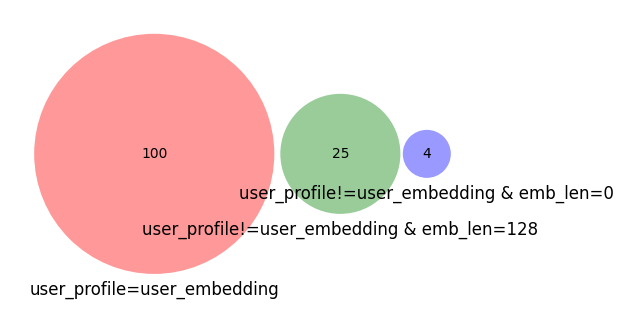

In [23]:
set_cold_cold = set(df_test_cold.filter((pl.col("split_dev_from_user_profile") == "test_cold")&(pl.col("split_from_user_embedding") == "test_cold"))["user_id"])
set_warm_cold_128 = set(df_test_cold.filter((pl.col("split_dev_from_user_profile") == "test_warm")&(pl.col("split_from_user_embedding") == "test_cold")&(pl.col("cf-bpr").list.len() == 128))["user_id"])
set_warm_cold_0 = set(df_test_cold.filter((pl.col("split_dev_from_user_profile") == "test_warm")&(pl.col("split_from_user_embedding") == "test_cold")&(pl.col("cf-bpr").list.len() == 0))["user_id"])

plt.figure(figsize=(6, 6))
venn3 = matplotlib_venn.venn3(
    [set_cold_cold, set_warm_cold_128, set_warm_cold_0], 
    set_labels=["user_profile=user_embedding", "user_profile!=user_embedding & emb_len=128", "user_profile!=user_embedding & emb_len=0"]
)